In [2]:
import numpy as np
from astropy.io import fits
import astropy.units as u
from importlib import reload

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Circle
from matplotlib.animation import FFMpegWriter, PillowWriter
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams['image.origin']='lower'
plt.rcParams['animation.html'] = 'html5'
plt.rcParams.update({'image.origin': 'lower',
                     'image.interpolation':'nearest'})

import esc_fresnel

import esc_fresnel.utils as utils
from esc_fresnel.math_module import xp, xcipy, ensure_np_array
from esc_fresnel.imshows import imshow1, imshow2, imshow3, imshow
import esc_fresnel.esc_fresnel as esc
import esc_fresnel.esc_optics as esc_optics

dm_flat = utils.load_fits(esc_fresnel.path/'dm-commands/esc_fresnel_dm_flat.fits')
dh_command = utils.load_fits(esc_fresnel.path/'dm-commands/esc_fresnel_dm_dh_command_1e-9.fits')





In [27]:
beamwalk_data = utils.load_pickle(esc_fresnel.path/'data/esc_beamwalk_with_m4_2.pkl')


In [16]:
beamwalk_data['all_images'].shape, beamwalk_data['pointing_pdf'].ravel()[:, None, None].shape

((3600, 300, 300), (3600, 1, 1))

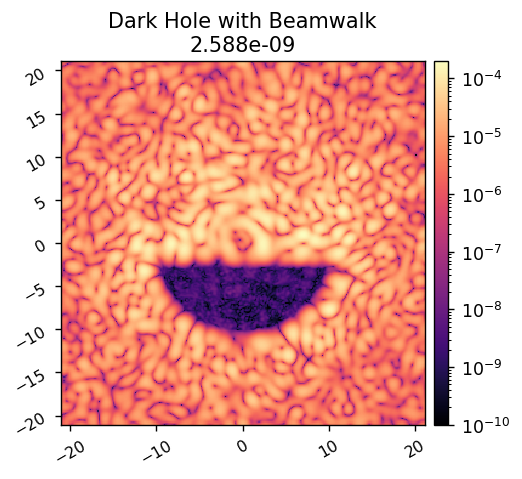

In [28]:

# total_im = xp.sum(beamwalk_data['all_images'], axis=0)
total_im = xp.sum(beamwalk_data['all_images'][:1800] * beamwalk_data['pointing_pdf'].ravel()[:1800, None, None], axis=0)
contrast_with_beamwalk = utils.mean(total_im, beamwalk_data['coro_mask'])

imshow1(
    total_im, 
    f'Dark Hole with Beamwalk\n{contrast_with_beamwalk:.3e}', 
    lognorm=1, 
    pxscl=beamwalk_data['pxscl'],
    vmin=1e-10, 
)

In [21]:
def create_ones_array(size, up_to_index):
  """
  Creates a NumPy array of a specified size, 
  with ones up to a given index and zeros afterward.

  Args:
    size: The total size of the array.
    up_to_index: The index up to which the array should contain ones.

  Returns:
    A NumPy array with ones up to the specified index and zeros afterward.
  """
  arr = np.zeros(size)
  arr[:up_to_index] = 1
  return arr

0


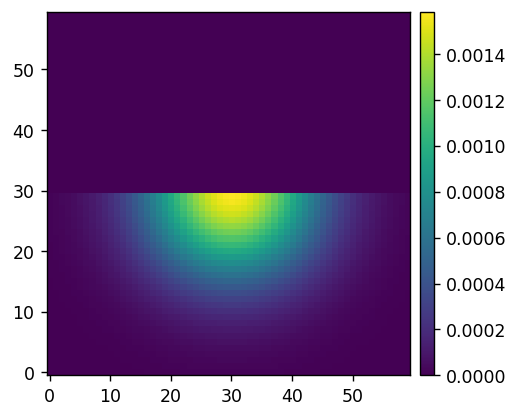

<Quantity [[-60., -60.],
           [-58., -60.],
           [-56., -60.],
           ...,
           [ 54.,  58.],
           [ 56.,  58.],
           [ 58.,  58.]] mas>

In [24]:
imshow(
    [beamwalk_data['pointing_pdf']*xp.array(create_ones_array(3600, 1800)).reshape(60,60)],
)

beamwalk_data['pointing_samples']

In [26]:
beamwalk_data['pointing_samples'][0].to_value(u.mas)

array([-60., -60.])

In [37]:
def create_anim(
        beamwalk_data,
        numframes=None, 
        cmaps=['magma', 'viridis', 'magma', 'magma'],
        norms=[None]*4,
        extents=[None]*4,
        title_fs=14,
        interval=0.01, # in seconds
        wspace=None,
        hspace=None,
        figsize=(20,8),
        dpi=125,
    ):
    numframes = beamwalk_data['all_images'].shape[0] if numframes is None else numframes
    print(numframes)

    jitter = beamwalk_data['jitter_std'].to_value(u.mas)
    m4_fsm_ratio = beamwalk_data['m4_fsm_ratio']

    nominal_im = ensure_np_array(beamwalk_data['nominal_im'])
    nominal_contrast = float(beamwalk_data['nominal_contrast'])
    beamwalk_ims = ensure_np_array(beamwalk_data['all_images'])
    contrasts = ensure_np_array(beamwalk_data['contrasts'])
    pointing_pdf = ensure_np_array(beamwalk_data['pointing_pdf'])
    pointing_sampling = beamwalk_data['pointing_sampling']
    pointing_samples = ensure_np_array(beamwalk_data['pointing_samples'])
    coro_mask = ensure_np_array(beamwalk_data['coro_mask'])

    i = 0

    im_with_beamwalk = beamwalk_ims[i]
    contrast_with_beamwalk = contrasts[i]
    pointing_offset = pointing_samples[i].to_value(u.mas)
    current_pdf_status = pointing_pdf * create_ones_array(3600, i).reshape(60,60) 
    total_beamwalk_im = xp.sum(beamwalk_ims[:i] * pointing_pdf.ravel()[:i, None, None], axis=0)
    total_contrast = np.mean( total_beamwalk_im[coro_mask] )

    fig, axs = plt.subplots(nrows=1, ncols=4, figsize=figsize, dpi=dpi)
    fig.suptitle(f'Jitter = {jitter:.1f} mas, M4-FSM Correction Ratio = {m4_fsm_ratio:.2f}', fontsize=16)

    ax = axs[0]
    im1 = ax.imshow(nominal_im, norm=norms[0], cmap=cmaps[0], extent=extents[0])
    im1_title = ax.set_title(f'Nominal Dark Hole Image\nContrast = {nominal_contrast}', fontsize=title_fs)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im1, cax=cax)

    ax = axs[1]
    im2 = ax.imshow(current_pdf_status, norm=norms[1], cmap=cmaps[1], extent=extents[1])
    im2_title = ax.set_title(f'Pointing Offset = ( {pointing_offset[0]:.1f} mas, {pointing_offset[0]:.1f} mas )', fontsize=title_fs)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im2, cax=cax)

    ax = axs[2]
    im3 = ax.imshow(im_with_beamwalk, norm=norms[2], cmap=cmaps[2], extent=extents[2])
    im3_title = ax.set_title(f'Instantaneous Dark Hole with Beamwalk\nContrast = {contrast_with_beamwalk}', fontsize=title_fs)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im3, cax=cax)

    ax = axs[3]
    im4 = ax.imshow(total_beamwalk_im, norm=norms[3], cmap=cmaps[3], extent=extents[3])
    im4_title = ax.set_title(f'Total Dark Hole with Beamwalk\nContrast = {total_contrast}', fontsize=title_fs)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im4, cax=cax)

    plt.subplots_adjust(wspace=wspace, hspace=hspace)

    def animate(i):

        im_with_beamwalk = beamwalk_ims[i]
        contrast_with_beamwalk = contrasts[i]
        pointing_offset = pointing_samples[i].to_value(u.mas)
        current_pdf_status = pointing_pdf * create_ones_array(3600, i).reshape(60,60) 
        total_beamwalk_im = xp.sum(beamwalk_ims[:i] * pointing_pdf.ravel()[:i, None, None], axis=0)
        total_contrast = np.mean( total_beamwalk_im[coro_mask] )

        # im3_title.set_text(f'CAMSCI Image: {contrast:.2e}',)

        # im1.set_data(camlo_im)
        im2.set_data(current_pdf_status)
        im3.set_data(im_with_beamwalk)
        im4.set_data(total_beamwalk_im)

        im2_title.set_text(f'Pointing Offset = ( {pointing_offset[0]:.1f} mas, {pointing_offset[0]:.1f} mas )')
        im3_title.set_text(f'Instantaneous Dark Hole with Beamwalk\nContrast = {contrast_with_beamwalk}')
        im4_title.set_text(f'Total Dark Hole with Beamwalk\nContrast = {total_contrast}')

        # im1.set_clim([np.min(camlo_im), np.max(camlo_im)])
        # im2.set_clim([np.min(diff_im), np.max(diff_im)])
        # im6.set_clim([np.min(lo_command), np.max(lo_command)])
        # im3.set_clim([np.min(del_command), np.max(del_command)])
        
    anim = matplotlib.animation.FuncAnimation(fig, animate, frames=numframes, interval=interval/1000) # wants interval in ms
    return anim

3600


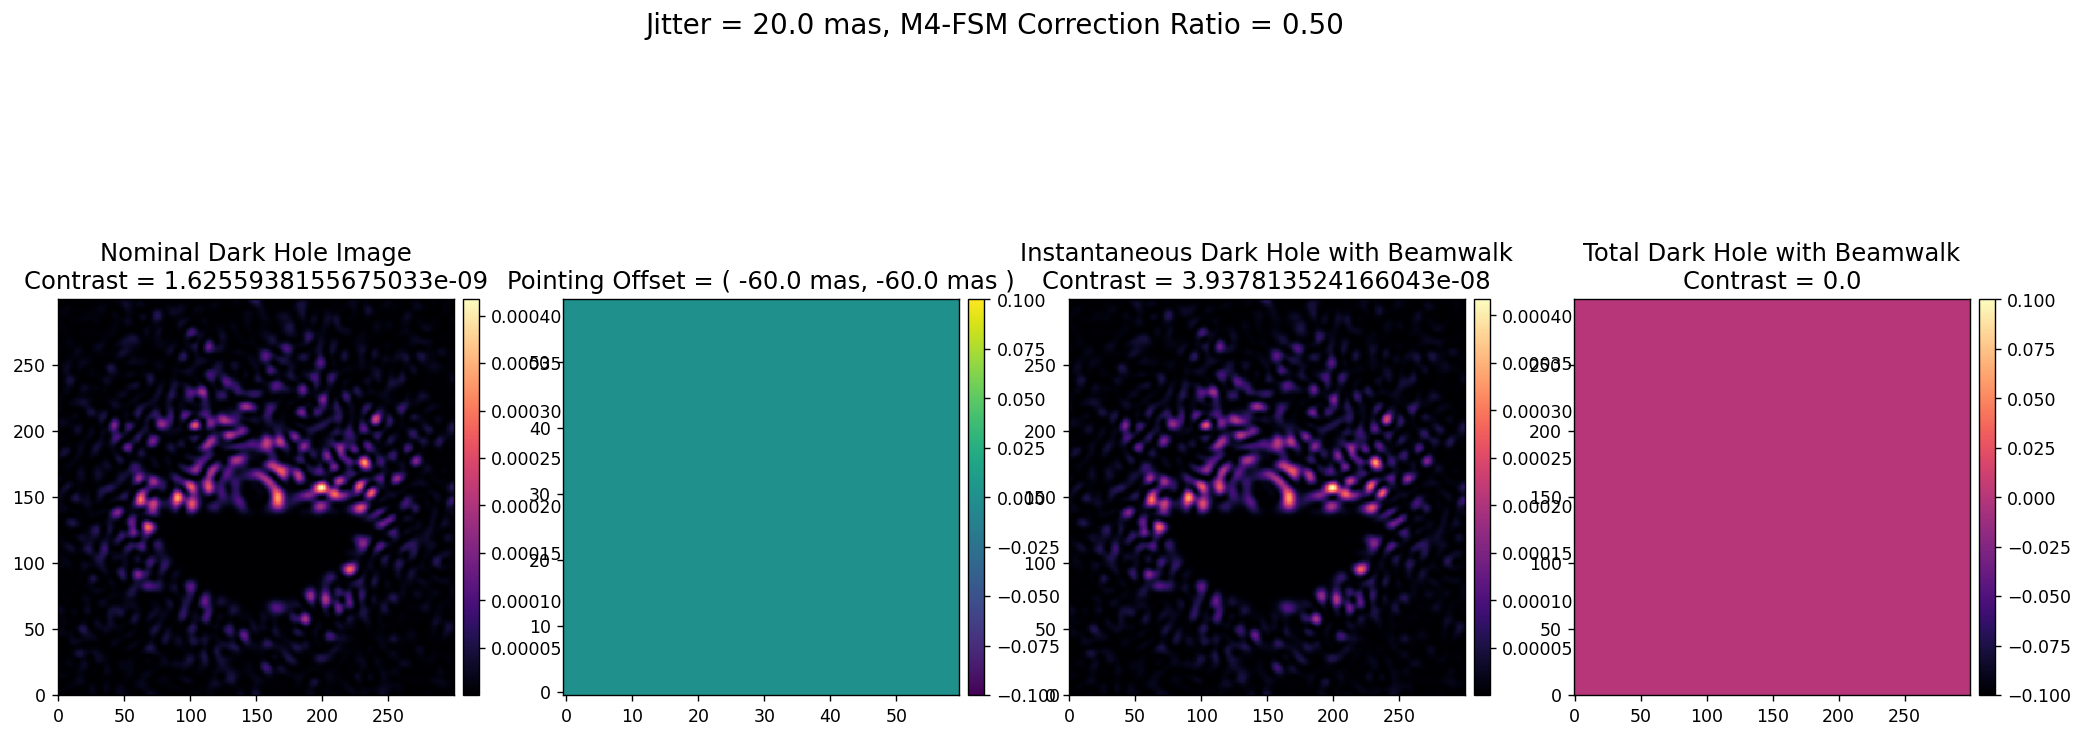

In [38]:

anim = create_anim(
    beamwalk_data, 
    # numframes=100,
    # cmap4='viridis', cmap5='viridis', cmap6='viridis', 
    # norm3=norm3,
    # norm4=norm4,
    # norm5=norm5,
    # # norm6=norm6,
    # extent3=camsci_extent,
    # # interval=100,
    # interval=interval, # in ms
    # wspace=0.3,
)